In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-09 14:22:15.898267


# Recluster neurons

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04a_neurons"
adata_path = input_dir / "scanvi_neuron_adata.h5ad"
bdata_path = input_dir / "seurat_neuron_adata.h5ad"

output_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
adata = sc.read_h5ad(adata_path)
bdata = sc.read_h5ad(bdata_path)

# Neighbors graph

In [6]:
sc.pp.neighbors(adata, use_rep = 'X_scVI_scanvi_neuron', random_state = 0)
sc.pp.neighbors(bdata, use_rep = 'X_scVI_seurat_neuron', random_state = 0)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
sc.tl.umap(adata, random_state = 0)
sc.tl.umap(bdata, random_state = 0)

In [8]:
sc.tl.leiden(adata, key_added='neuron_recluster', resolution=1)
sc.tl.leiden(bdata, key_added='neuron_recluster', resolution=1)

/tmp/ipykernel_12724/70920631.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='neuron_recluster', resolution=1)


In [9]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

In [10]:
assign_cell_type_colors(adata,  key="scanvi_labels")
assign_cell_type_colors(adata,  key="seurat_labels")
assign_cell_type_colors(bdata,  key="scanvi_labels")
assign_cell_type_colors(bdata,  key="seurat_labels")

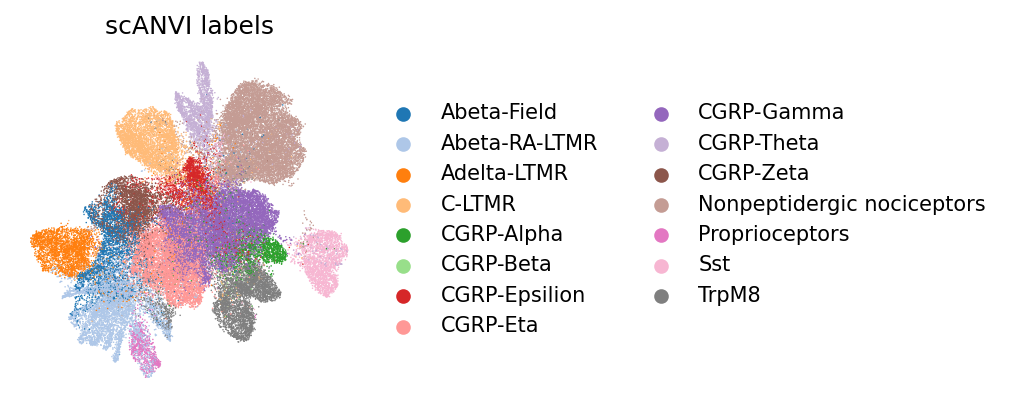

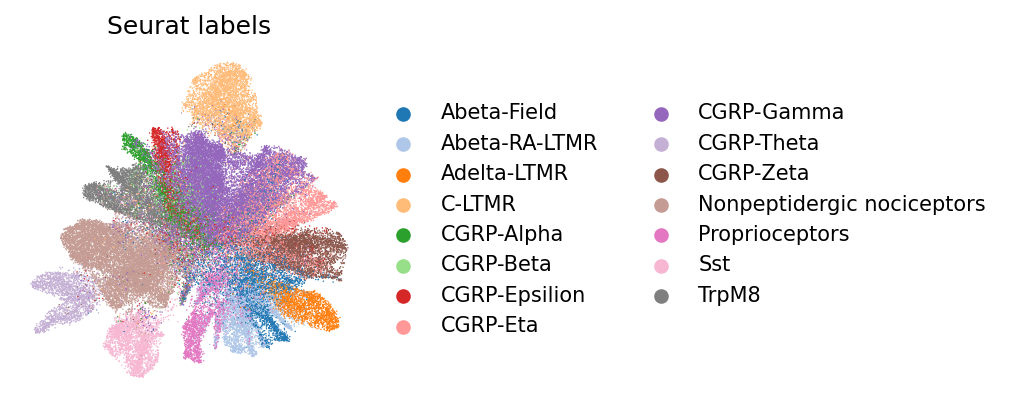

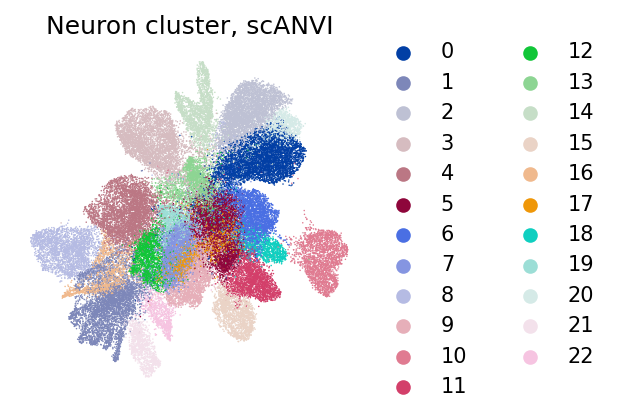

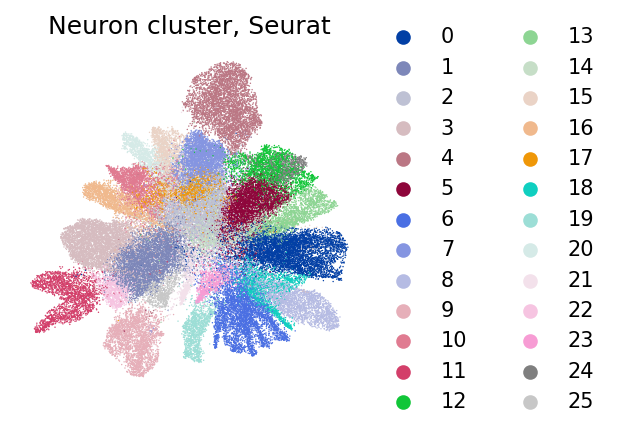

In [11]:
sc.pl.umap(adata, color = 'scanvi_labels', frameon = False, title = 'scANVI labels')
sc.pl.umap(bdata, color = 'seurat_labels', frameon = False, title = 'Seurat labels')
sc.pl.umap(adata, color = 'neuron_recluster', frameon = False, title = 'Neuron cluster, scANVI')
sc.pl.umap(bdata, color = 'neuron_recluster', frameon = False, title = 'Neuron cluster, Seurat')

# Summary

In [12]:
# Seurat summary as that's what we will likely proceed with
egfp = bdata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = bdata.obs["dTomato_Seq2_hi"].astype(bool)
dual = bdata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": bdata.obs.index,
    "seurat_label": bdata.obs["seurat_labels"],
    "scanvi_label": bdata.obs["scanvi_labels"],
    "confidence": bdata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

In [13]:
df[df["EGFP_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
aogalboa-1,aogalboa-1,CGRP-Gamma,CGRP-Eta,NaN
cfckmnhc-1,cfckmnhc-1,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,NaN
ckgddhbd-1,ckgddhbd-1,CGRP-Eta,SGC,NaN
higbejdg-1,higbejdg-1,C-LTMR,SGC,NaN
ahgdffna-1,ahgdffna-1,CGRP-Eta,CGRP-Eta,NaN
akfjbdhd-1,akfjbdhd-1,TrpM8,Pericyte,NaN
canljbbi-1,canljbbi-1,CGRP-Gamma,CGRP-Gamma,NaN
eaiehejo-1,eaiehejo-1,Abeta-Field,Adelta-LTMR,NaN
eckbhagl-1,eckbhagl-1,Nonpeptidergic nociceptors,Pericyte,NaN
ihadecfn-1,ihadecfn-1,CGRP-Gamma,CGRP-Gamma,NaN


In [14]:
df[df["dTom_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
achecihm-1,achecihm-1,CGRP-Gamma,CGRP-Gamma,NaN
aemkjdhf-1,aemkjdhf-1,CGRP-Gamma,CGRP-Gamma,NaN
agbmnepe-1,agbmnepe-1,CGRP-Gamma,CGRP-Gamma,High
behbjfkc-1,behbjfkc-1,CGRP-Gamma,Pericyte,NaN
bekmepom-1,bekmepom-1,CGRP-Gamma,CGRP-Gamma,NaN
...,...,...,...,...
dhlbnpjp-1,dhlbnpjp-1,CGRP-Gamma,CGRP-Eta,NaN
gkcjkgon-1,gkcjkgon-1,CGRP-Gamma,CGRP-Gamma,NaN
jmdegfji-1,jmdegfji-1,CGRP-Gamma,CGRP-Gamma,NaN
jmepnhcc-1,jmepnhcc-1,CGRP-Gamma,CGRP-Gamma,NaN


In [15]:
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN
jkabbhfm-1,jkabbhfm-1,CGRP-Gamma,CGRP-Gamma,NaN
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,High


# Export

In [16]:
adata_path = os.path.join(output_dir, 'neurons-scanvi.h5ad')
bdata_path = os.path.join(output_dir, 'neurons-seurat.h5ad')

adata.write_h5ad(adata_path, compression='gzip')
bdata.write_h5ad(bdata_path, compression='gzip')

print(adata_path)
print(bdata_path)

/home/workspace/projects/drg/data/h5ad/export_04/04b_reclustered/neurons-scanvi.h5ad
/home/workspace/projects/drg/data/h5ad/export_04/04b_reclustered/neurons-seurat.h5ad


## Session info

In [17]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [18]:
adata

AnnData object with n_obs × n_vars = 57016 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

# test recompute neighbors use scanvi

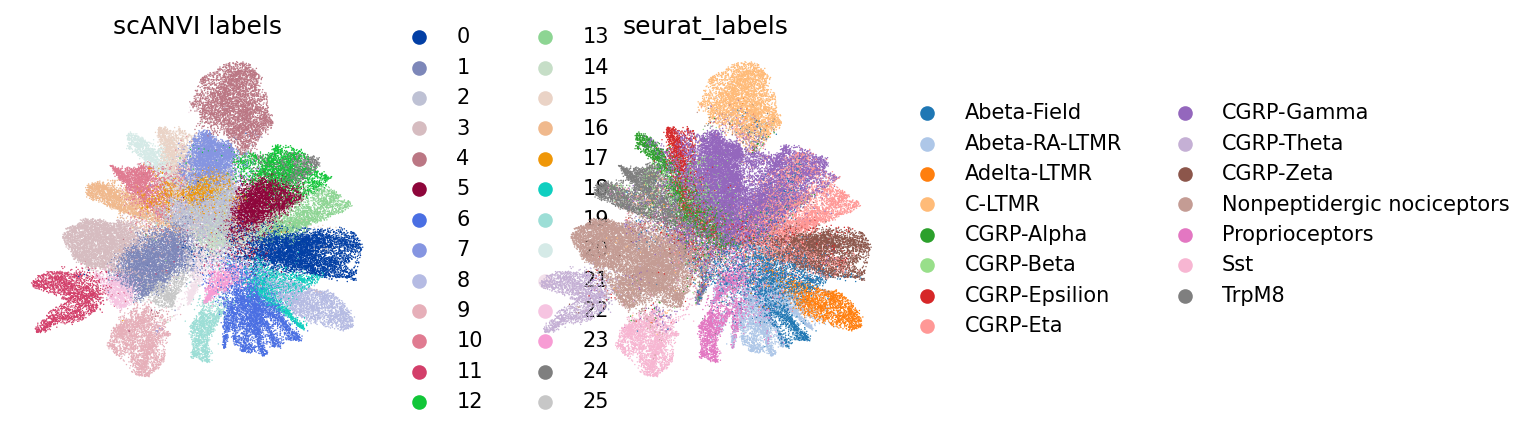

In [59]:
sc.pl.umap(bdata, color = ['neuron_recluster', 'seurat_labels'], frameon = False, title = 'scANVI labels')

In [30]:
bdata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    63569
True        22
Name: count, dtype: int64

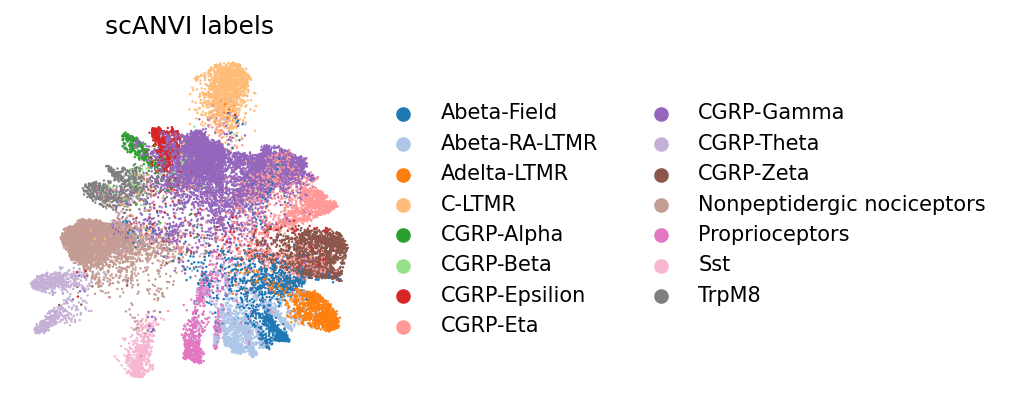

In [44]:
bdata_subset = bdata[bdata.obs['total_counts'] > 1000].copy()
sc.pl.umap(bdata_subset, color = 'seurat_labels', frameon = False, title = 'scANVI labels')

In [45]:
bdata_subset.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22370
True        19
Name: count, dtype: int64

# test

In [94]:
bdata_copy = bdata.copy()

In [96]:
bdata.X = bdata.layers['log1p'].copy()

In [97]:
sc.pp.regress_out(bdata, ["total_counts"])
sc.pp.scale(bdata, max_value=10)

In [108]:
sc.pp.pca(bdata, n_comps = 10)
sc.pp.neighbors(bdata,random_state = 0, n_neighbors = 10)
#sc.pp.neighbors(bdata,random_state = 0, use_rep = 'X_scVI_seurat_neuron', n_neighbors = 30)


In [109]:
sc.tl.umap(bdata, random_state = 0)

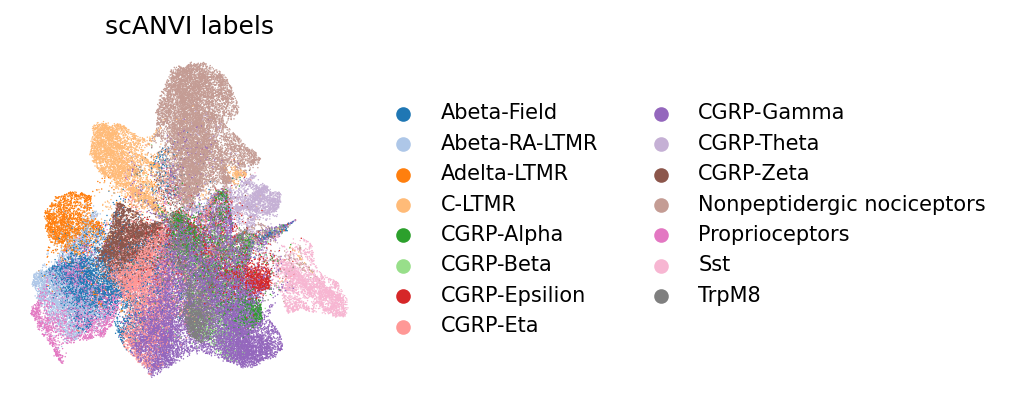

In [110]:
sc.pl.umap(bdata, color = 'seurat_labels', frameon = False, title = 'scANVI labels')

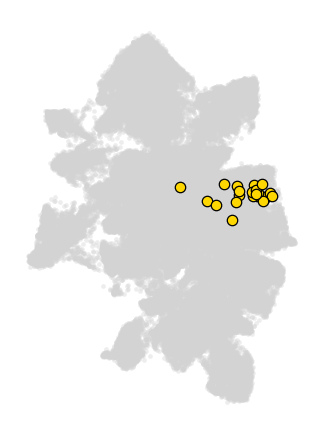

In [101]:
import matplotlib.pyplot as plt

# Column to visualize
col = "EGFP_dTomato_dual_hi"

# Get UMAP coordinates
x, y = bdata.obsm["X_umap"][:, 0], bdata.obsm["X_umap"][:, 1]

# Boolean mask
mask = bdata.obs[col].astype(bool).values

plt.figure(figsize=(3, 3))

# Plot FALSE (background)
plt.scatter(
    x[~mask],
    y[~mask],
    s=5,
    c="lightgray",
    linewidths=0,
    alpha=0.4,
)

# Plot TRUE (highlight)
plt.scatter(
    x[mask],
    y[mask],
    s=25,
    c="gold",         # ← change color if you want
    edgecolors="black",
    linewidths=0.6,
    alpha=1.0,
)

# Minimalist formatting
ax = plt.gca()
ax.set_aspect("equal", "box")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

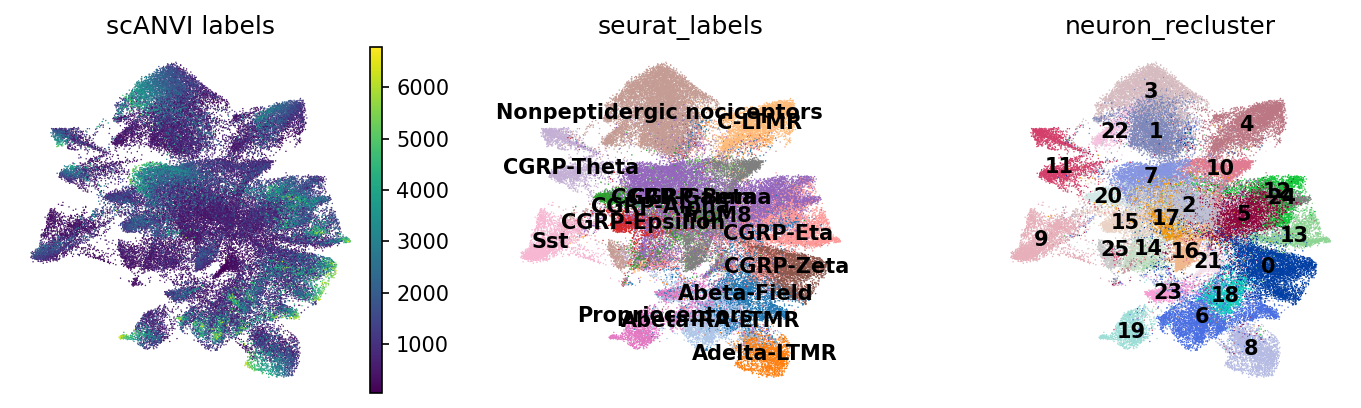

In [105]:
sc.pl.umap(bdata, color = ['total_counts', 'seurat_labels', 'neuron_recluster'], frameon = False, title = 'scANVI labels', legend_loc = 'on data')

In [104]:
import pandas as pd

# Boolean mask for dual-positive cells
dual_mask = bdata.obs["EGFP_dTomato_dual_hi"].astype(bool)

# Build a small dataframe for only dual-positive rows
df_dual = pd.DataFrame({
    "barcode": bdata.obs.index[dual_mask],
    "seurat_label": bdata.obs["seurat_labels"][dual_mask],
    "scanvi_label": bdata.obs["scanvi_labels"][dual_mask],
    "neuron_recluster": bdata.obs["neuron_recluster"][dual_mask],
    "total_counts": bdata.obs["total_counts"][dual_mask],
})

df_dual

,barcode,seurat_label,scanvi_label,neuron_recluster,total_counts
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,24,3766.0
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,24,2052.0
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,24,2259.0
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,24,2249.0
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,5,2411.0
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,24,1718.0
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,5,3259.0
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,5,1661.0
jkabbhfm-1,jkabbhfm-1,CGRP-Gamma,CGRP-Gamma,24,926.0
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,5,2757.0
